# Лабораторная работа №1


## Шаг 1. Загрузка данных

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print('Размер тренировочной выборки:', X_train.shape)  # (60000, 28, 28)
print('Размер тестовой выборки:     ', X_test.shape)   # (10000, 28, 28)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Размер тренировочной выборки: (60000, 28, 28)
Размер тестовой выборки:      (10000, 28, 28)


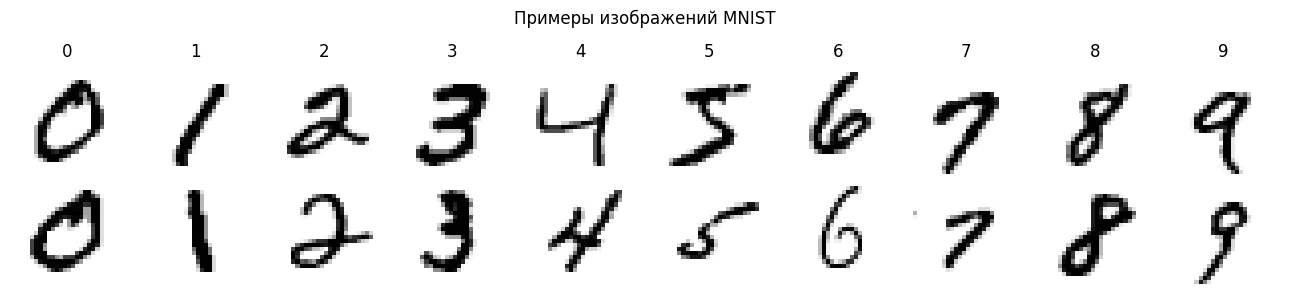

In [ ]:
fig, axes = plt.subplots(2, 10, figsize=(13, 3))
for digit in range(10):
    for row in range(2):
        idx = np.where(y_train == digit)[0][row]
        axes[row, digit].imshow(X_train[idx], cmap='gray_r')
        axes[row, digit].axis('off')
        if row == 0:
            axes[row, digit].set_title(str(digit))
plt.suptitle('Примеры изображений MNIST')
plt.tight_layout()
plt.show()

## Шаг 2. Предобработка

In [ ]:
# Разворачиваем 28x28 в вектор 784 и нормализуем в [0, 1]
X_train = X_train.reshape(-1, 784) / 255.0
X_test  = X_test.reshape(-1, 784)  / 255.0

# One-hot кодирование меток: 3 -> [0,0,0,1,0,0,0,0,0,0]
def one_hot(labels, n_classes=10):
  Y = np.zeros((len(labels), n_classes))
  Y[np.arange(len(labels)), labels] = 1
  return Y

Y_train = one_hot(y_train)
Y_test  = one_hot(y_test)

print('X_train:', X_train.shape, '  Y_train:', Y_train.shape)
print('X_test: ', X_test.shape,  '  Y_test: ', Y_test.shape)
print()
print('Метка y_train[0] =', y_train[0], '  →  one-hot:', Y_train[0])

X_train: (60000, 784)   Y_train: (60000, 10)
X_test:  (10000, 784)   Y_test:  (10000, 10)

Метка y_train[0] = 5   →  one-hot: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


## Шаг 3. Функции активации

In [ ]:
def relu(Z):
  return np.maximum(0, Z)

def relu_grad(Z):
  return (Z > 0).astype(float)

def softmax(Z):
  Z = Z - Z.max(axis=1, keepdims=True)
  e = np.exp(Z)
  return e / e.sum(axis=1, keepdims=True)

## Шаг 4. Инициализация весов

In [ ]:
np.random.seed(42)

W1 = np.random.randn(784, 300) * np.sqrt(2 / 784)  # (784, 300)
b1 = np.zeros((1, 300))                              # (1,   300)

W2 = np.random.randn(300, 10)  * np.sqrt(2 / 300)   # (300,  10)
b2 = np.zeros((1, 10))                               # (1,    10)

print('W1:', W1.shape, '  b1:', b1.shape)
print('W2:', W2.shape, '  b2:', b2.shape)

W1: (784, 300)   b1: (1, 300)
W2: (300, 10)   b2: (1, 10)


## Шаг 5. Прямой проход



In [ ]:
def forward(X):
  Z1 = np.dot(X, W1) + b1
  A1 = relu(Z1)
  Z2 = np.dot(A1, W2) + b2
  Y_hat = softmax(Z2)
  return Y_hat, Z1, A1

## Шаг 6. Обратный проход



In [ ]:
def backward(X, Y, Y_hat, Z1, A1):
  m = X.shape[0]
  # Выходной слой
  d2  = (Y_hat - Y) / m
  dW2 = np.dot(A1.T, d2)
  db2 = d2.sum(axis=0, keepdims=True)

  # Скрытый слой
  d1  = np.dot(d2, W2.T) * relu_grad(Z1)
  dW1 = np.dot(X.T, d1)
  db1 = d1.sum(axis=0, keepdims=True)

  return dW1, db1, dW2, db2

## Шаг 7. Обучение

In [ ]:
# Гиперпараметры
lr         = 0.1
batch_size = 64
epochs     = 20

loss_history = []
acc_history  = []

for epoch in range(1, epochs + 1):
    t0 = time.time()

    # Перемешиваем данные
    idx = np.random.permutation(len(X_train))
    X_sh, Y_sh = X_train[idx], Y_train[idx]

    # Проходим по батчам
    for i in range(0, len(X_sh), batch_size):
        Xb = X_sh[i : i + batch_size]
        Yb = Y_sh[i : i + batch_size]

        Y_hat, Z1, A1 = forward(Xb)
        dW1, db1_g, dW2, db2_g = backward(Xb, Yb, Y_hat, Z1, A1)

        W1 -= lr * dW1;  b1 -= lr * db1_g
        W2 -= lr * dW2;  b2 -= lr * db2_g

    # Метрики на всей тренировочной выборке
    Y_hat_all, _, _ = forward(X_train)
    loss = -np.sum(Y_train * np.log(Y_hat_all + 1e-15)) / len(X_train)
    acc  = np.mean(Y_hat_all.argmax(axis=1) == y_train)
    err  = 1 - acc

    loss_history.append(loss)
    acc_history.append(acc)

    print(f'Эпоха {epoch:2d} | Потери: {loss:.4f} | Точность: {acc*100:.2f}% | Ошибка: {err*100:.2f}% | Время: {time.time()-t0:.1f}с')

Эпоха  1 | Потери: 0.2290 | Ошибка: 6.41% | Время: 4.8с
Эпоха  2 | Потери: 0.1515 | Ошибка: 4.28% | Время: 8.0с
Эпоха  3 | Потери: 0.1165 | Ошибка: 3.22% | Время: 4.6с
Эпоха  4 | Потери: 0.0935 | Ошибка: 2.57% | Время: 7.1с
Эпоха  5 | Потери: 0.0854 | Ошибка: 2.40% | Время: 4.7с
Эпоха  6 | Потери: 0.0684 | Ошибка: 1.84% | Время: 4.7с
Эпоха  7 | Потери: 0.0607 | Ошибка: 1.61% | Время: 7.3с
Эпоха  8 | Потери: 0.0543 | Ошибка: 1.39% | Время: 4.6с
Эпоха  9 | Потери: 0.0464 | Ошибка: 1.17% | Время: 7.4с
Эпоха 10 | Потери: 0.0424 | Ошибка: 1.08% | Время: 4.6с
Эпоха 11 | Потери: 0.0364 | Ошибка: 0.87% | Время: 4.8с
Эпоха 12 | Потери: 0.0345 | Ошибка: 0.85% | Время: 7.1с
Эпоха 13 | Потери: 0.0294 | Ошибка: 0.62% | Время: 4.5с
Эпоха 14 | Потери: 0.0272 | Ошибка: 0.53% | Время: 7.4с
Эпоха 15 | Потери: 0.0263 | Ошибка: 0.55% | Время: 4.6с
Эпоха 16 | Потери: 0.0221 | Ошибка: 0.40% | Время: 4.9с
Эпоха 17 | Потери: 0.0204 | Ошибка: 0.34% | Время: 6.4с
Эпоха 18 | Потери: 0.0189 | Ошибка: 0.29% | Врем

## Шаг 8. Результаты

In [ ]:
Y_hat_test, _, _ = forward(X_test)
test_acc = np.mean(Y_hat_test.argmax(axis=1) == y_test)
print(f'Точность на тестовой выборке: {test_acc*100:.2f}%')
print(f'Ошибка классификации:         {(1-test_acc)*100:.2f}%')

Точность на тестовой выборке: 98.03%
Ошибка классификации:         1.97%


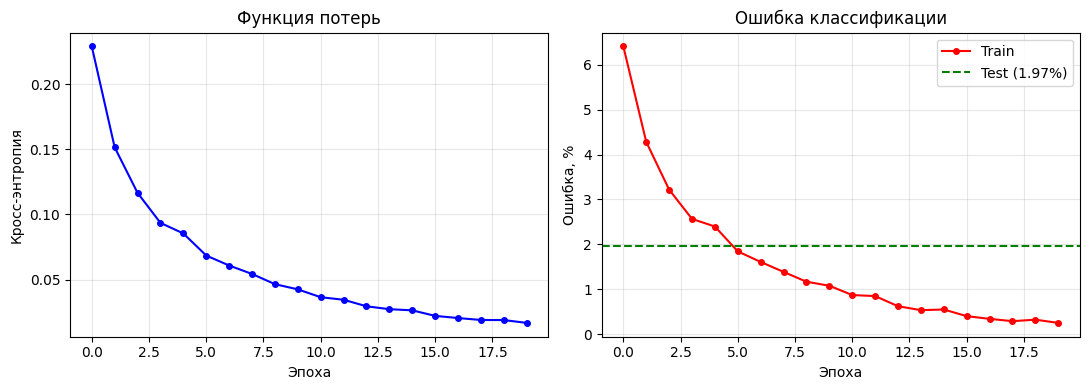

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(loss_history, 'b-o', markersize=4)
ax1.set_title('Функция потерь')
ax1.set_xlabel('Эпоха'); ax1.set_ylabel('Кросс-энтропия')
ax1.grid(True, alpha=0.3)

train_err = [(1 - a) * 100 for a in acc_history]
ax2.plot(train_err, 'r-o', markersize=4, label='Train')
ax2.axhline((1 - test_acc) * 100, color='g', linestyle='--',
            label=f'Test ({(1-test_acc)*100:.2f}%)')
ax2.set_title('Ошибка классификации')
ax2.set_xlabel('Эпоха'); ax2.set_ylabel('Ошибка, %')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()